In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [61]:
prices_raw_2 = pd.read_csv("prices_round_5_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_5_day_3.csv", sep = ";", index_col = "timestamp")
prices_raw_4 = pd.read_csv("prices_round_5_day_4.csv", sep = ";", index_col = "timestamp")
prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw_4.index = prices_raw_4.index + prices_raw_3.index.max() + 100
prices_raw = pd.concat([prices_raw_2, prices_raw_3, prices_raw_4], axis=0)
mid_prices = prices_raw[["product", "mid_price"]]
mid_prices = (
    mid_prices.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)
sp = mid_prices.filter(regex=r'^PANEL')

<Axes: xlabel='timestamp'>

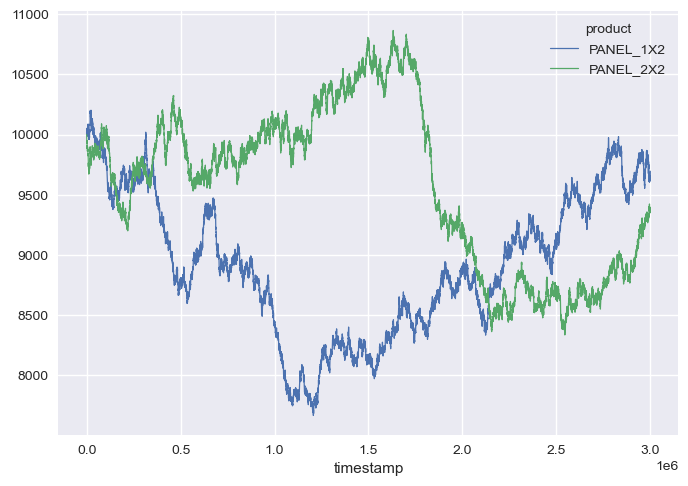

In [62]:
pair = sp[["PANEL_1X2", "PANEL_2X2"]]
pair.plot(lw=0.9)

In [63]:
log_pair = np.log(pair)

<Axes: xlabel='timestamp'>

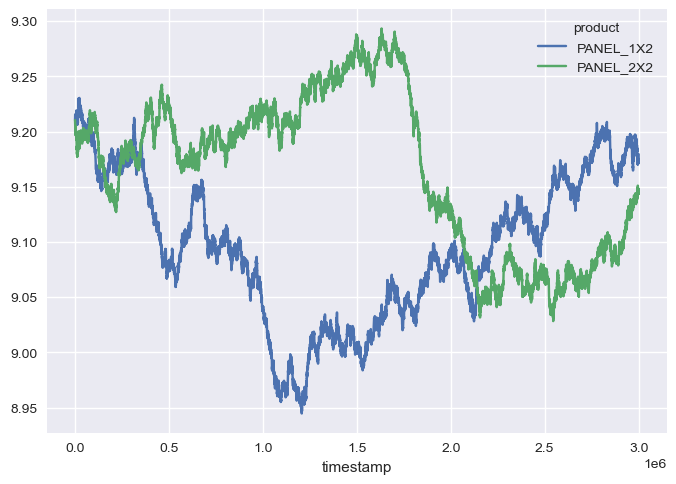

In [64]:
log_pair.plot()

In [65]:
y = "PANEL_1X2"
x = "PANEL_2X2"
import statsmodels.api as sm
X = sm.add_constant(log_pair[x])
est = sm.OLS(log_pair[y], X).fit()

beta = est.params[x]
alpha = est.params["const"]

y_pred = alpha + beta * log_pair[x]
spread = log_pair[y] - y_pred

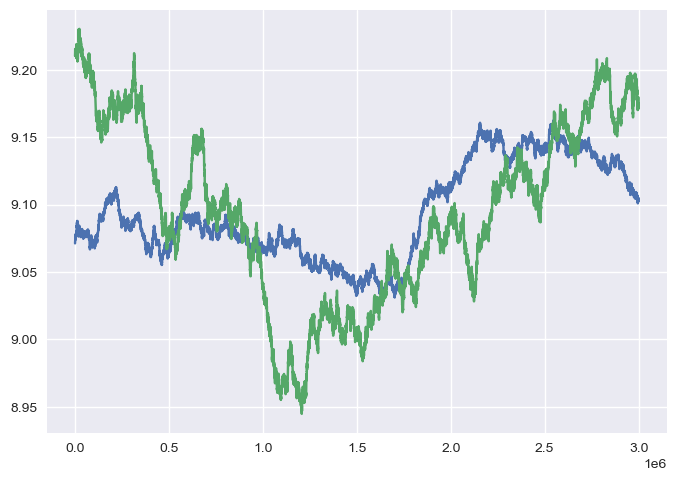

In [66]:
plt.plot(y_pred)
plt.plot(log_pair[y])

<Axes: xlabel='timestamp'>

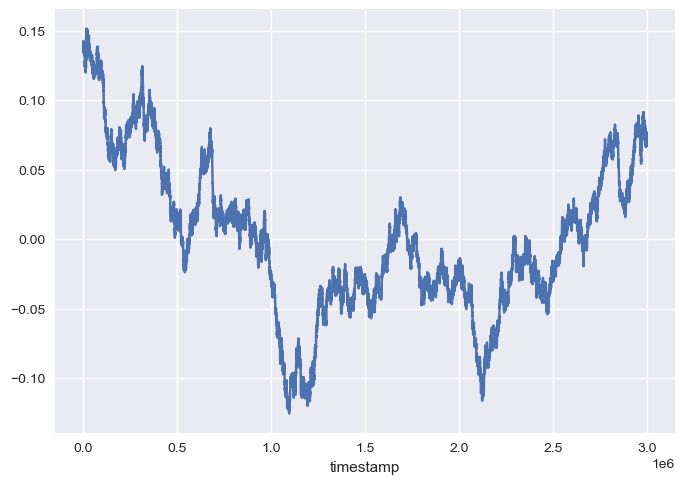

In [67]:
spread.plot()

<Axes: xlabel='timestamp'>

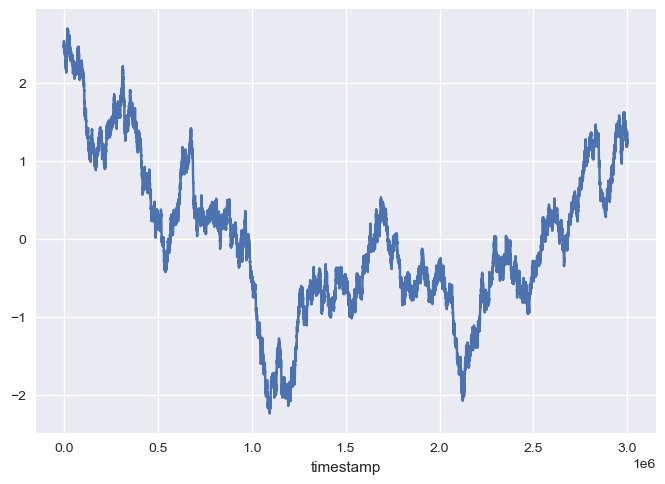

In [68]:
z_spread = spread / spread.std()
z_spread.plot()

In [69]:
import statsmodels.tsa.stattools as ts
cadf = ts.adfuller(spread)
print ('Augmented Dickey Fuller test statistic =',cadf[0])
print ('Augmented Dickey Fuller p-value =',cadf[1])
print ('Augmented Dickey Fuller 1%, 5% and 10% test statistics =',cadf[4])

Augmented Dickey Fuller test statistic = -2.3608775694705004
Augmented Dickey Fuller p-value = 0.1530841495553953
Augmented Dickey Fuller 1%, 5% and 10% test statistics = {'1%': np.float64(-3.4305680025880942), '5%': np.float64(-2.8616363512511263), '10%': np.float64(-2.5668212848307097)}


In [70]:
alpha

np.float64(13.684655128137374)

In [71]:
beta

np.float64(-0.5008962559589548)

In [72]:
spread.std()

0.05610591832106225